In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
adata1 = sc.read_h5ad(r"C:\Users\annam\Dissertation 2026\Data\Raw\GSE114725_raw.h5ad")

adata2 = sc.read_h5ad(r"C:\Users\annam\Dissertation 2026\Data\Raw\GSE176078_raw.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 47016 × 14875
    obs: 'patient', 'tissue', 'replicate', 'cluster'
AnnData object with n_obs × n_vars = 100064 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset'


In [3]:
for adata in [adata1, adata2]:
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        percent_top=None,
        log1p=False,
        inplace=True
    )

print(adata1.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())
print(adata2.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())

         n_genes_by_counts  total_counts  pct_counts_mt
cell_id                                                
246                    240         401.0       1.246883
260                    509         946.0       6.976744
346                    443         839.0       5.959476
188                    369         541.0       5.545287
33                     275         407.0       3.439803
                          n_genes_by_counts  total_counts  pct_counts_mt
CID3586_AAGACCTCAGCATGAG               1689        4581.0       1.506221
CID3586_AAGGTTCGTAGTACCT                779        1726.0       5.793743
CID3586_ACCAGTAGTTGTGGCC                514        1229.0       1.383238
CID3586_ACCCACTAGATGTCGG                609        1352.0       1.923077
CID3586_ACTGATGGTCAACTGT                807        1711.0      13.325541


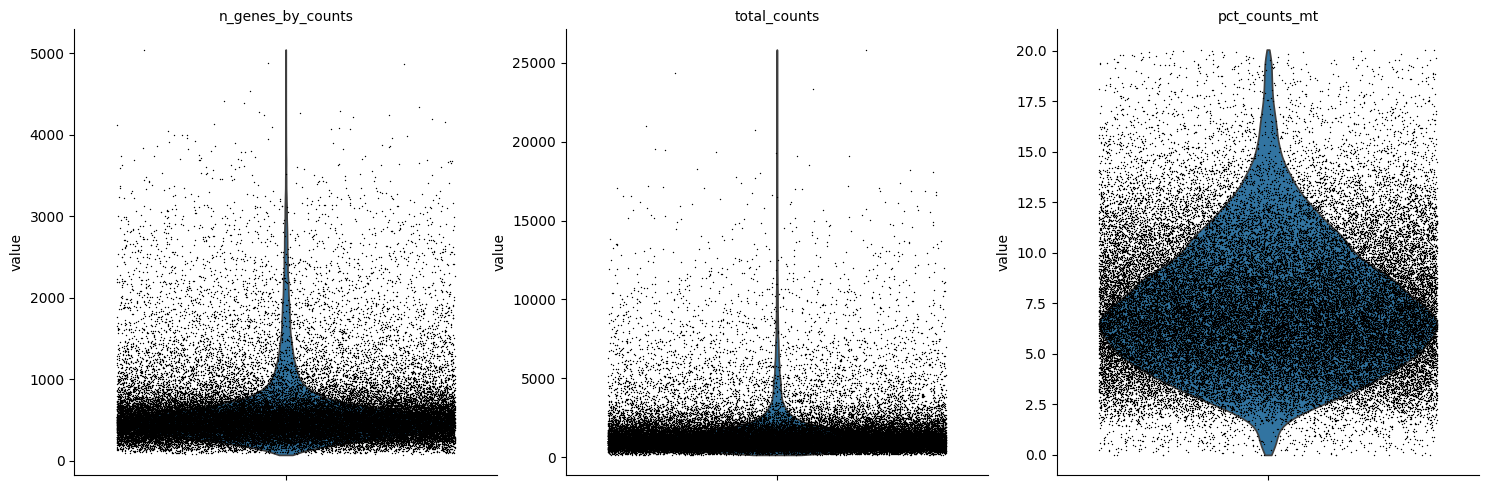

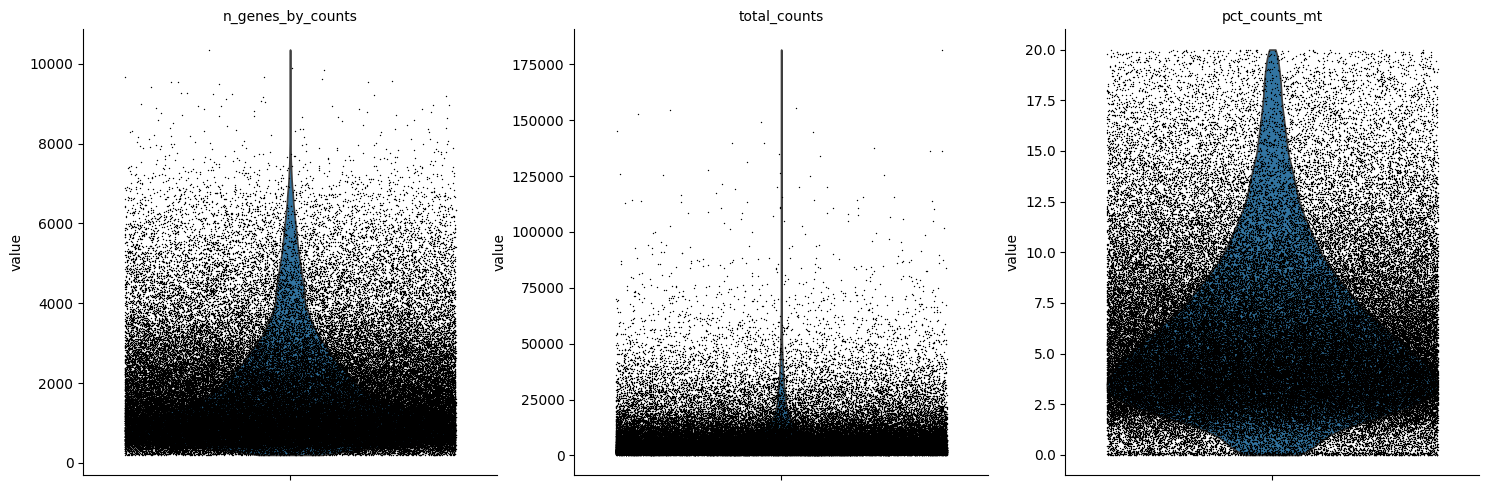

In [4]:
sc.pl.violin(
    adata1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

sc.pl.violin(
    adata2,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

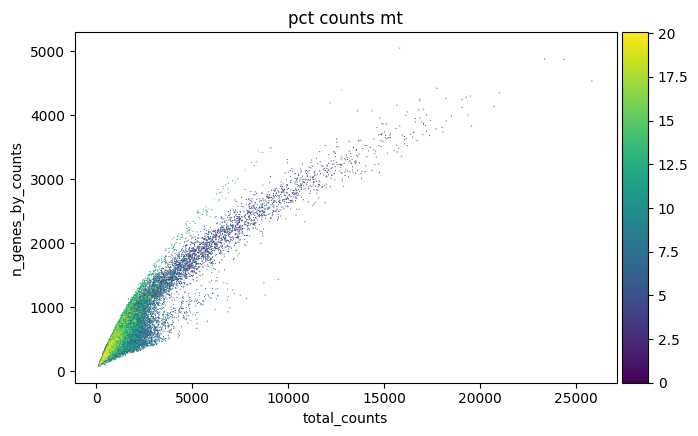

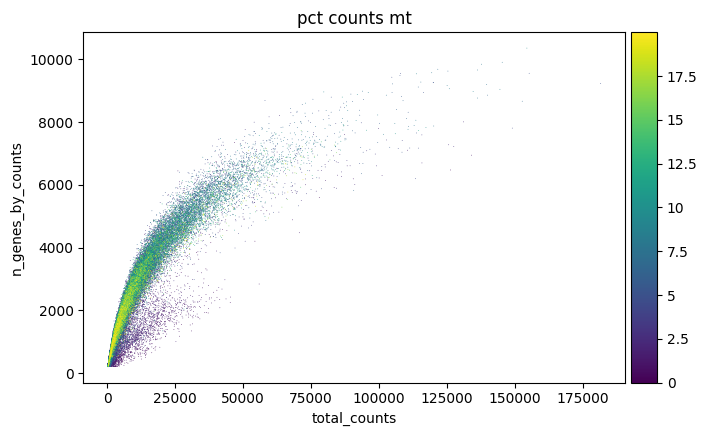

In [5]:
sc.pl.scatter(
    adata1,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

sc.pl.scatter(
    adata2,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

In [6]:
print("Before QC filtering:")
print("GSE114725:", adata1.n_obs, "cells,", adata1.n_vars, "genes")
print("GSE176078:", adata2.n_obs, "cells,", adata2.n_vars, "genes")

Before QC filtering:
GSE114725: 47016 cells, 14875 genes
GSE176078: 100064 cells, 29733 genes


In [7]:
adata1_qc = adata1[
    (adata1.obs["n_genes_by_counts"] > 200) &
    (adata1.obs["pct_counts_mt"] < 10)
].copy()

adata2_qc = adata2[
    (adata2.obs["n_genes_by_counts"] > 300) &
    (adata2.obs["pct_counts_mt"] < 10)
].copy()

print("After cell filtering:")
print("GSE114725:", adata1_qc.n_obs, "cells")
print("GSE176078:", adata2_qc.n_obs, "cells")

After cell filtering:
GSE114725: 36613 cells
GSE176078: 83033 cells


In [8]:
sc.pp.filter_genes(adata1_qc, min_cells=3)
sc.pp.filter_genes(adata2_qc, min_cells=3)

print("After gene filtering:")
print("GSE114725:", adata1_qc.n_obs, "cells,", adata1_qc.n_vars, "genes")
print("GSE176078:", adata2_qc.n_obs, "cells,", adata2_qc.n_vars, "genes")

After gene filtering:
GSE114725: 36613 cells, 14751 genes
GSE176078: 83033 cells, 27221 genes


In [9]:
!pip install scrublet

In [10]:
import scrublet as scr

Running Scrublet for GSE114725
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.87
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 1.2%
Elapsed time: 201.8 seconds


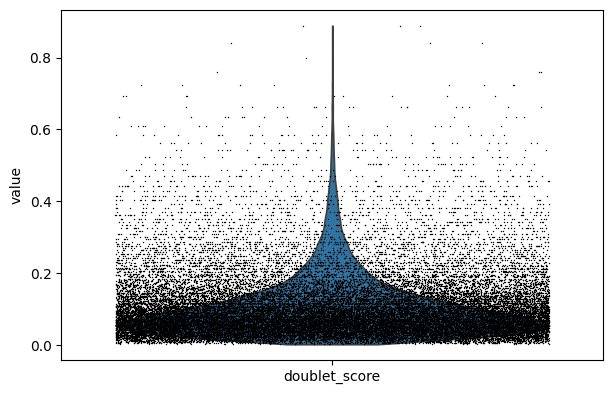

Cells before: 36613
Cells after: 36610
Doublets removed: 3
Running Scrublet for GSE176078
Preprocessing...


In [ ]:
def run_scrublet(adata, dataset_name):
    print(f"Running Scrublet for {dataset_name}")

    before = adata.n_obs

    scrub = scr.Scrublet(adata.X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets()

    adata.obs["doublet_score"] = doublet_scores
    adata.obs["predicted_doublet"] = predicted_doublets

    sc.pl.violin(adata, ["doublet_score"], jitter=0.4)

    adata = adata[~adata.obs["predicted_doublet"]].copy()

    print(f"Cells before: {before}")
    print(f"Cells after: {adata.n_obs}")
    print(f"Doublets removed: {before - adata.n_obs}")

    return adata


adata1_qc = run_scrublet(adata1_qc, "GSE114725")
adata2_qc = run_scrublet(adata2_qc, "GSE176078")

In [ ]:
for adata in [adata1, adata2]:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

print("Normalization complete.")